In [23]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from typing import Union
from qutip import basis

In [24]:
#parameters
omega_c = 2 * np.pi * 50 #MHz
omega_t = 2 * np.pi * 25 #MHz
T_t = 1 * np.pi/omega_t
T_c = 1 * np.pi/omega_c
tmax = T_c * 2 + T_t * 3
V_dd = 2 * np.pi * 1000 #MHz
tau_c = 548
tau_R = 505
gamma_c = 1/tau_c
gamma_R = 1/tau_R

In [25]:
tmax

0.08

In [26]:
#time list
tlist = np.linspace(0, tmax, 1000)

#control atom states
gc = basis(2,0) #|0>
rc = basis(2,1) #|1>

#dagger
gc_dag = gc.dag()  # <0|
rc_dag = rc.dag()  # <1|

#target atom states
gt = basis(3,0) 
et = basis(3,1)
rt = basis(3,2)

#dagger
gt_dag = gt.dag()
et_dag = et.dag()
rt_dag = rt.dag()

In [27]:
#control field
def Omega_c(t):
    if 0<=t<T_c:
        return omega_c
    elif T_c + 3 * T_t < t <= tmax:
        return - omega_c
    else:
        return 0

In [28]:
#target atoms
def Omega_p(t):
    if T_c<=t<T_c+T_t:
        return omega_t
    elif T_c + 2 * T_t <= t <= T_c + 3 * T_t:
        return omega_t
    else:
        return 0


def Omega_p2(t):
    if T_c + T_t <= t <= T_c + 2 * T_t:
        return - omega_t
    else:
        return 0


In [29]:
#hc = np.array([[0, 0, 0],
#               [0, 0, omega_c/2],
#               [0, omega_c/2, 0]])

#hrr = np.array([[0, 0, 0],
#                [0, 0, 0],
#                [0, 0, 1]])

#hRR = np.array([[0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 1]])

#hamiltonian
def hc(t):
    return Omega_c(t)/2 * (gc * rc_dag + rc * gc_dag)

hrr = rc * rc_dag
hRR = rt * rt_dag

In [30]:
hc(T_c/2)

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[  0.         157.07963268]
 [157.07963268   0.        ]]

In [31]:
def ht(t):
    return Omega_p(t)/2 * (rt * et_dag + et * rt_dag)

def ht2(t):
    return Omega_p2(t)/2 * (rt * gt_dag + gt * rt_dag)

In [32]:
print(ht(T_c + T_t/2))

print(ht2(T_c + 3 * T_t/2))

Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.          0.          0.        ]
 [ 0.          0.         78.53981634]
 [ 0.         78.53981634  0.        ]]
Quantum object: dims=[[3], [3]], shape=(3, 3), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ -0.          -0.         -78.53981634]
 [ -0.          -0.          -0.        ]
 [-78.53981634  -0.          -0.        ]]


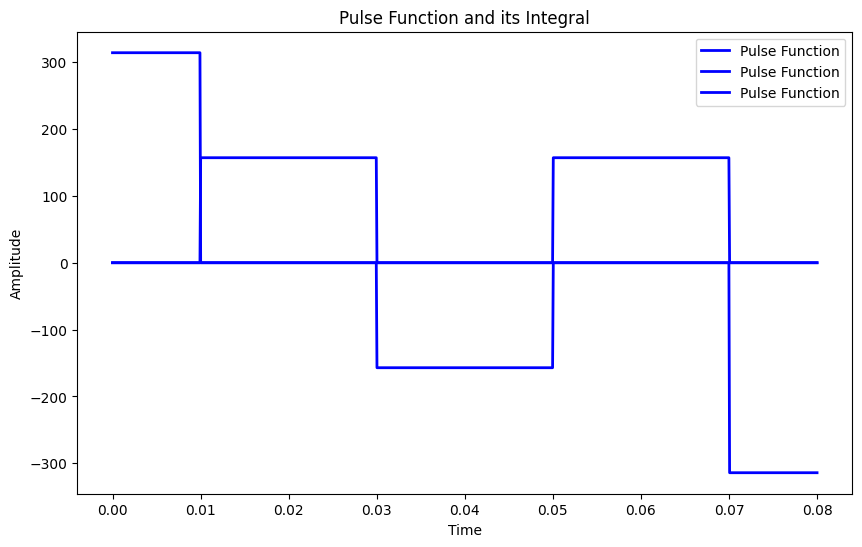

In [33]:
# 可视化函数和积分
t_plot = np.linspace(0, tmax, 1000)
pulse_valuesp = [Omega_p(t) for t in t_plot]
pulse_valuesp2 = [Omega_p2(t) for t in t_plot]
pulse_valuesc = [Omega_c(t) for t in t_plot]

plt.figure(figsize=(10, 6))
plt.plot(t_plot, pulse_valuesp, 'b-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesp2, 'b-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesc, 'b-', linewidth=2, label='Pulse Function')


plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()

In [34]:
L_c = np.sqrt(gamma_c) * (gc * rc_dag)
L_R = np.sqrt(gamma_R) * (gt * rt_dag)

In [35]:
def Hnhermitian(t):
    h1 = tensor(hc(t), Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), ht(t)) + tensor(Qobj(np.eye(2)), ht2(t))
    h2 = V_dd * tensor(hrr, hRR)
    h31 = -1j/2 * (L_c.dag() * L_c)
    h32 = -1j/2 * (L_R.dag() * L_R)
    h3 = tensor(h31, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), h32)
    return h1 + h2 + h3

In [36]:
Hnhermitian(0.01)

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dense, isherm=False
Qobj data =
[[   0.        +0.j            0.        +0.j
     0.        +0.j            0.        +0.j
     0.        +0.j            0.        +0.j        ]
 [   0.        +0.j            0.        +0.j
    78.53981634+0.j            0.        +0.j
     0.        +0.j            0.        +0.j        ]
 [   0.        +0.j           78.53981634+0.j
     0.        -0.0009901j     0.        +0.j
     0.        +0.j            0.        +0.j        ]
 [   0.        +0.j            0.        +0.j
     0.        +0.j            0.        -0.00091241j
     0.        +0.j            0.        +0.j        ]
 [   0.        +0.j            0.        +0.j
     0.        +0.j            0.        +0.j
     0.        -0.00091241j   78.53981634+0.j        ]
 [   0.        +0.j            0.        +0.j
     0.        +0.j            0.        +0.j
    78.53981634+0.j         6283.18530718-0.00190251j]]

In [37]:
c_ops = tensor(L_c, Qobj(np.eye(3))) + tensor(Qobj(np.eye(2)), L_R)

In [38]:
c_ops

Quantum object: dims=[[2, 3], [2, 3]], shape=(6, 6), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.         0.         0.04449942 0.04271788 0.         0.        ]
 [0.         0.         0.         0.         0.04271788 0.        ]
 [0.         0.         0.         0.         0.         0.04271788]
 [0.         0.         0.         0.         0.         0.04449942]
 [0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.        ]]

In [39]:
psi00 = tensor(gc,gt)
psi11 = tensor(gc,et)
psi_0 = tensor(Qobj(np.eye(2)),gt)
psi_1 = tensor(Qobj(np.eye(2)),et)
psi_2 = tensor(Qobj(np.eye(2)),rt)


In [40]:
mc = mcsolve(Hnhermitian, psi00, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag()])

10.0%. Run time:  30.30s. Est. time left: 00:00:04:32
20.0%. Run time:  61.00s. Est. time left: 00:00:04:04
30.0%. Run time:  92.69s. Est. time left: 00:00:03:36
40.0%. Run time: 123.41s. Est. time left: 00:00:03:05
50.0%. Run time: 154.14s. Est. time left: 00:00:02:34
60.0%. Run time: 184.93s. Est. time left: 00:00:02:03
70.0%. Run time: 215.60s. Est. time left: 00:00:01:32
80.0%. Run time: 246.30s. Est. time left: 00:00:01:01
90.0%. Run time: 276.95s. Est. time left: 00:00:00:30
100.0%. Run time: 307.72s. Est. time left: 00:00:00:00
Total run time: 308.36s


In [41]:
mc1 = mcsolve(Hnhermitian, psi11, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag(), psi_2*psi_2.dag()])

10.0%. Run time:  38.87s. Est. time left: 00:00:05:49
20.0%. Run time:  77.74s. Est. time left: 00:00:05:10
30.0%. Run time: 116.67s. Est. time left: 00:00:04:32
40.0%. Run time: 155.60s. Est. time left: 00:00:03:53
50.0%. Run time: 194.56s. Est. time left: 00:00:03:14
60.0%. Run time: 233.99s. Est. time left: 00:00:02:35
70.0%. Run time: 272.63s. Est. time left: 00:00:01:56
80.0%. Run time: 311.47s. Est. time left: 00:00:01:17
90.0%. Run time: 350.42s. Est. time left: 00:00:00:38
100.0%. Run time: 389.23s. Est. time left: 00:00:00:00
Total run time: 390.05s


In [42]:
print(mc.expect[0][999])
print(mc1.expect[1][999])


0.9999997548250653
0.9999990307698036


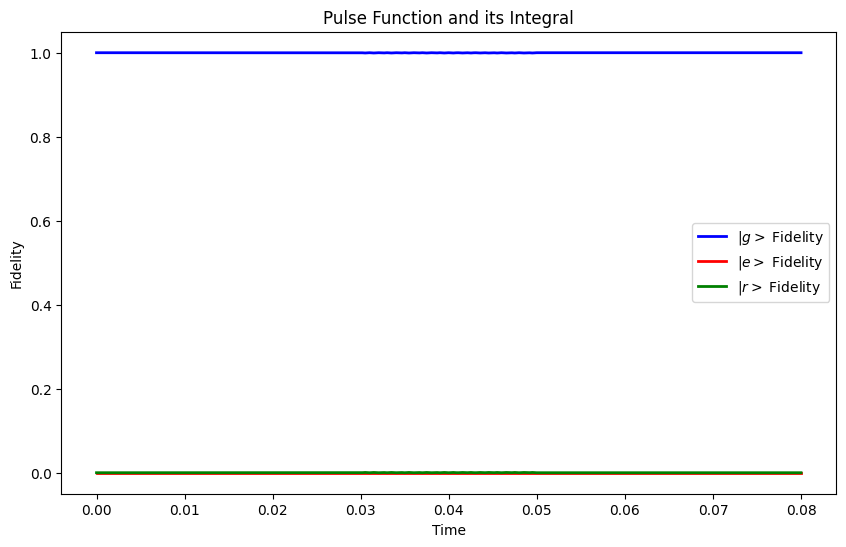

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc.expect[0],'-b',lw=2,label='$|g>$ Fidelity')

plt.plot(tlist,mc.expect[1],'-r',lw=2,label='$|e>$ Fidelity')

plt.plot(tlist,mc.expect[2],'-g',lw=2,label='$|r>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()

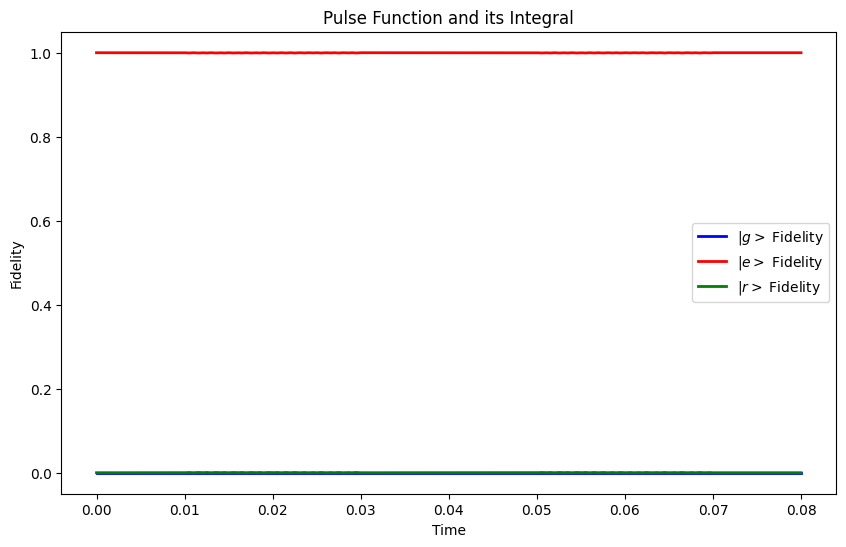

In [44]:
plt.figure(figsize=(10, 6))

plt.plot(tlist,mc1.expect[0],'-b',lw=2,label='$|g>$ Fidelity')

plt.plot(tlist,mc1.expect[1],'-r',lw=2,label='$|e>$ Fidelity')

plt.plot(tlist,mc1.expect[2],'-g',lw=2,label='$|r>$ Fidelity')

plt.xlabel('Time')
plt.ylabel('Fidelity')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(False)
plt.show()
plt.show()